In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
import statsmodels.api as sm
from helper_functions_objs import *

## Pre-process the decision variables

In [2]:
# create decision variable files with headers 
dv_names = ['RT_W', 'RT_D', 'RT_F', 'TT_D', 'TT_F', 'LMA_W', 'LMA_D', 'LMA_F', \
    'AP_W', 'AP_D', 'AP_F', 'IT_W', 'IT_D', 'IT_F', 'IP_W', 'IP_D', 'IP_F', \
    'INF_W', 'INF_D', 'INF_F', 'NRR_W', 'CRL', 'CRH', 'WR1', 'SCR', 'GQR', \
    'NRR_F', 'WR2_W', 'WR2_D', 'WR2_F']

dv_base_filename = 'objectives_dvs_nd/dvs_base_nd_truncated_extremes.csv'
dv_iu_filename = 'objectives_dvs_nd/dvs_IU_nd_truncated_extremes.csv'

trigger_names = ['RT_W', 'INF_W', 'RT_D', 'TT_D', 'INF_D', 'RT_F', 'TT_F', 'INF_F']
alloc_names = ['LMA_W', 'LMA_D', 'LMA_F', 'AP_W', 'AP_D', 'AP_F']
dvs_relevant = trigger_names + alloc_names
infra_W = ['NRR_W', 'CRL', 'CRH', 'WR1', 'GQR', 'WR2_W']
infra_D = ['SCR', 'WR2_D']
infra_F = ['NRR_F', 'WR2_F']

util_abbrevs = ['W', 'D', 'F']
util_names_dict = {'W': 'Watertown', 'D': 'Dryville', 'F': 'Fallsland'}

num_dvs = len(dv_names)
print('Number of decision variables: ', num_dvs)
# import decision variable files 
dv_iu = pd.read_csv(dv_iu_filename, index_col=None, header=None)
dv_base = pd.read_csv(dv_base_filename, index_col=None, header=None)

# replace column headers with abbreviated names
dv_iu.columns = dv_names
dv_base.columns = dv_names

dv_IU_triggers = dv_iu[trigger_names]
dv_base_triggers = dv_base[trigger_names]
dvs_base_relevant = dv_base[dvs_relevant]
dvs_IU_relevant = dv_iu[dvs_relevant]
infra_W_triggers_IU = dv_iu[infra_W]
infra_D_triggers_IU = dv_iu[infra_D]   
infra_F_triggers_IU = dv_iu[infra_F]
infra_W_triggers_base = dv_base[infra_W]
infra_D_triggers_base = dv_base[infra_D]
infra_F_triggers_base = dv_base[infra_F]

Number of decision variables:  30


In [3]:
print(f"There are {dv_iu.shape[0]} IU solutions and {dv_base.shape[0]} base solutions.")

There are 628 IU solutions and 46 base solutions.


In [4]:
# normalize the decision variables
dv_iu_norm = (dv_iu - dv_iu.min()) / (dv_iu.max() - dv_iu.min())
dv_base_norm = (dv_base - dv_base.min()) / (dv_base.max() - dv_base.min())

## Plot DV distributions

In [7]:
sol_high_coop_IU = find_sols(dv_iu, "high_coop", [0.4])
sol_low_coop_IU = find_sols(dv_iu, "low_coop", [0.4])

sol_high_coop_base = find_sols(dv_base, "high_coop", [0.4])
sol_low_coop_base = find_sols(dv_base, "low_coop", [0.4])

In [8]:
sol_high_coop_base

[2, 6, 13, 19, 22, 26, 29, 36, 40, 42, 43, 44, 45]

In [6]:
# save the solution indices to csv files
pd.DataFrame(sol_high_coop_IU).to_csv('sol_high_coop_IU.csv', index=False, header=False)
pd.DataFrame(sol_low_coop_IU).to_csv('sol_low_coop_IU.csv', index=False, header=False)
pd.DataFrame(sol_high_coop_base).to_csv('sol_high_coop_base.csv', index=False, header=False)
pd.DataFrame(sol_low_coop_base).to_csv('sol_low_coop_base.csv', index=False, header=False)

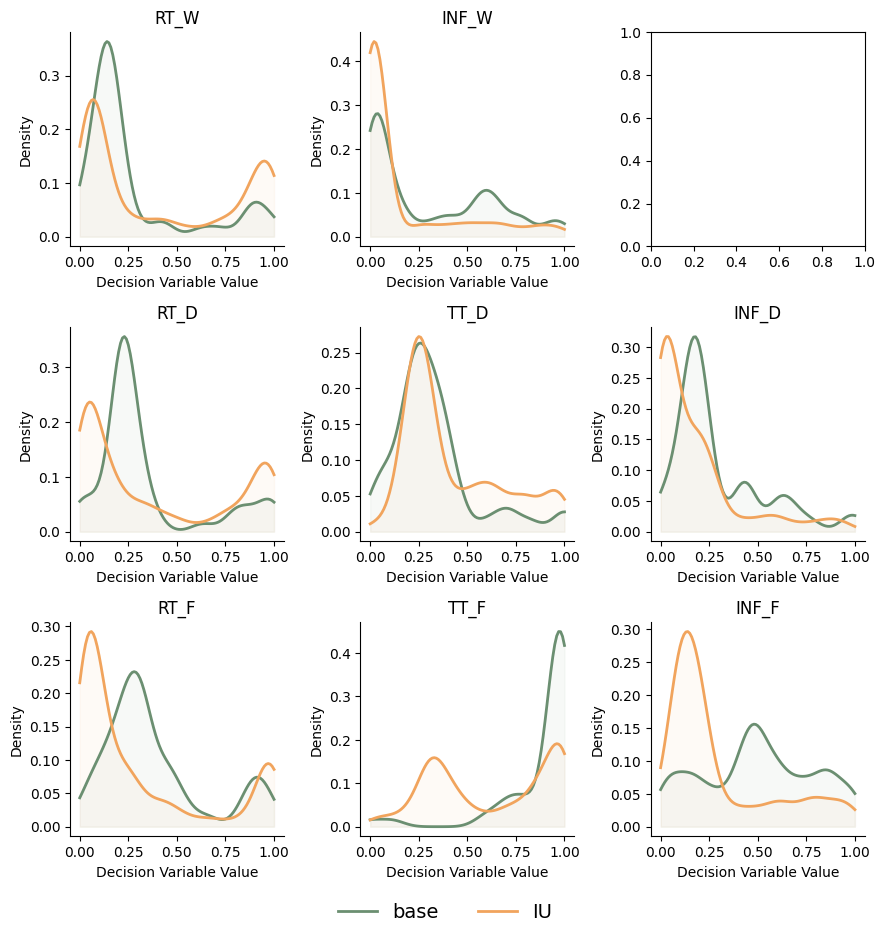

In [ ]:
# create a 2 x 4 subplot to plot distribution of each decision variable 
# plot for IU
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()
# remove the last empty subplot
#axes[-1].remove()

color_dict_coop = ['#20A39E', "#FFBA49", '#EF5B5B']

for i, dv in enumerate(trigger_names):
    ax = axes[i]
    if i > 1:
        ax = axes[i+1]
    plot_kde(dv_base_triggers, dv, f'{dv}', ax, '#6B8F71', 'base', spec_sols=False, linestyle='solid')
    plot_kde(dv_IU_triggers, dv, f'{dv}', ax, '#F1A45D', 'IU', spec_sols=False, linestyle='solid')

# plot the legend where the last subplot was removed
handles, labels = axes[0].get_legend_handles_labels()
# insert legend in the center of the figure
fig.legend(handles, labels, loc='lower center', fontsize=14, frameon=False, ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('figures/dvs_IU_base_hist_triggersnd.pdf')
plt.show()